In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory
file_names = []
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        file_names.append(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [3]:
!pip install tensorflow

In [4]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Dropout, Flatten
from tensorflow.keras.layers import RandomFlip, RandomZoom, RandomContrast
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
import os

data_path = os.path.abspath("..\\dataset")

In [6]:
import os

data_path = os.path.abspath("..\\dataset")
image_extensions = {'.jpg', '.jpeg', '.png', '.gif', '.bmp', '.tiff'}

if not os.path.isdir(data_path):
    raise FileNotFoundError(f"Dataset folder not found: {data_path}")

for class_name in os.listdir(data_path):
    class_folder = os.path.join(data_path, class_name)
    if os.path.isdir(class_folder):
        num_images = sum(
            1 for file in os.listdir(class_folder)
            if os.path.isfile(os.path.join(class_folder, file))
            and os.path.splitext(file)[1].lower() in image_extensions
        )
        print(f"Class {class_name}: {num_images} images")


Class AVM: 673 images
Class Normal: 2156 images
Class Ulcer: 472 images


In [7]:
train_set, valid_set = keras.utils.image_dataset_from_directory(
    data_path, image_size=(256, 256), validation_split=0.2, subset="both", seed=0 
)

Found 3301 files belonging to 3 classes.
Using 2641 files for training.
Using 660 files for validation.


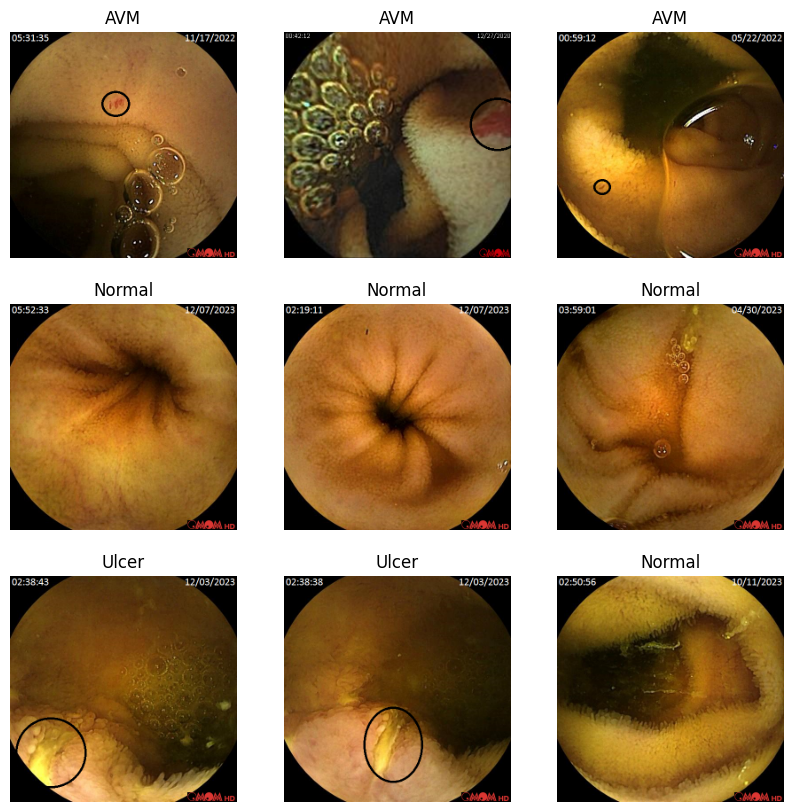

In [8]:
class_names = train_set.class_names
for images, labels in train_set.take(1):
    plt.figure(figsize=(10, 10))
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i].numpy()])
        plt.axis("off")
    plt.show()

In [9]:
model = Sequential([
    keras.Input(shape=(256,256,3)),
    Conv2D(32, (3,3), activation = "relu"),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation = "relu"),
    MaxPooling2D(2,2),
    Conv2D(128, (3,3), activation = "relu"),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation = "relu"),
    Dropout(0.5),
    Dense(3, activation = "softmax")
])
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

In [10]:
checkpoint_cb = ModelCheckpoint("best_model.keras", save_best_only=True)
early_stopping_cb = EarlyStopping(patience=5, restore_best_weights=True)

In [11]:
history = model.fit(train_set, validation_data = valid_set, epochs=15,
                    callbacks = [checkpoint_cb, early_stopping_cb])

Epoch 1/15
83/83 ━━━━━━━━━━━━━━━━━━━━ 82s 944ms/step - accuracy: 0.6895 - loss: 20.8860 - val_accuracy: 0.7667 - val_loss: 0.5431
Epoch 2/15
83/83 ━━━━━━━━━━━━━━━━━━━━ 77s 923ms/step - accuracy: 0.8239 - loss: 0.4919 - val_accuracy: 0.9076 - val_loss: 0.3201
Epoch 3/15
83/83 ━━━━━━━━━━━━━━━━━━━━ 73s 881ms/step - accuracy: 0.9000 - loss: 0.2797 - val_accuracy: 0.9652 - val_loss: 0.1640
Epoch 4/15
83/83 ━━━━━━━━━━━━━━━━━━━━ 80s 966ms/step - accuracy: 0.9621 - loss: 0.1308 - val_accuracy: 0.9833 - val_loss: 0.0572
Epoch 5/15
83/83 ━━━━━━━━━━━━━━━━━━━━ 77s 923ms/step - accuracy: 0.9796 - loss: 0.0642 - val_accuracy: 0.9985 - val_loss: 0.0140
Epoch 6/15
83/83 ━━━━━━━━━━━━━━━━━━━━ 78s 939ms/step - accuracy: 0.9943 - loss: 0.0267 - val_accuracy: 0.9985 - val_loss: 0.0049
Epoch 7/15
83/83 ━━━━━━━━━━━━━━━━━━━━ 68s 812ms/step - accuracy: 0.9917 - loss: 0.0319 - val_accuracy: 0.9985 - val_loss: 0.0036
Epoch 8/15
83/83 ━━━━━━━━━━━━━━━━━━━━ 72s 864ms/step - accuracy: 0.9962 - loss: 0.0139 - val_acc

In [12]:
# Get class names
class_names = valid_set.class_names  # List of class labels

# Extract true labels and images from the test dataset
true_labels = []
images = []

for image_batch, label_batch in valid_set:
    images.append(image_batch.numpy())  # Convert tensors to numpy arrays
    true_labels.append(label_batch.numpy())

# Flatten lists into arrays
true_labels = np.concatenate(true_labels, axis=0)
images = np.concatenate(images, axis=0)

# Get model predictions
pred_probs = model.predict(images)  # Predict probabilities
pred_labels = np.argmax(pred_probs, axis=1)  # Convert probabilities to class indices


21/21 ━━━━━━━━━━━━━━━━━━━━ 5s 217ms/step


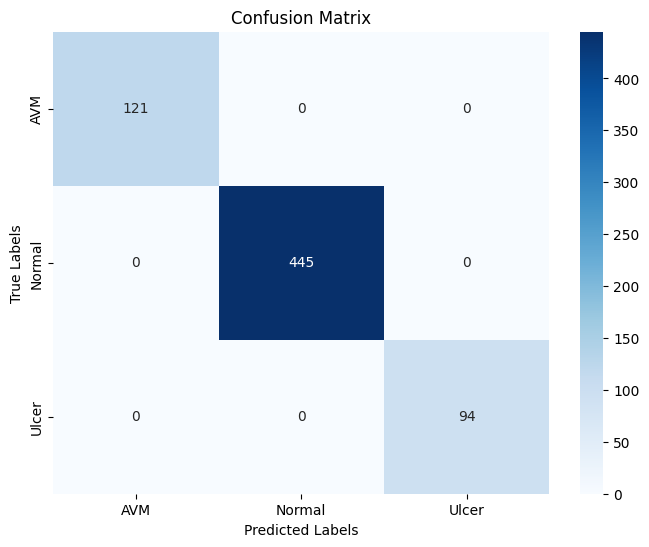

In [13]:
# Compute confusion matrix
cm = confusion_matrix(true_labels, pred_labels)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()


In [14]:
# print final train and validation accuracy from history
train_acc = history.history["accuracy"][-1]
val_acc = history.history["val_accuracy"][-1]

print(f"Training accuracy (final epoch): {train_acc:.4f}")
print(f"Validation accuracy (final epoch): {val_acc:.4f}")

# Optional: overall metrics on validation set
val_loss, val_acc_eval = model.evaluate(valid_set, verbose=0)
print(f"Validation accuracy (model.evaluate): {val_acc_eval:.4f}")

Training accuracy (final epoch): 0.9879
Validation accuracy (final epoch): 0.9985
Validation accuracy (model.evaluate): 1.0000
